In [32]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import os

zip_path = '/content/drive/MyDrive/data.zip'

# Check if the file exists in Drive
if os.path.exists(zip_path):
    print("Found the zip file in Drive! Unzipping now...")
    # Unzip into the local Colab environment (quietly with -q)
    !unzip -q "$zip_path" -d /content/
    print("✅ Unzipping Complete. Files are ready.")
else:
    print("❌ Error: Could not find 'data.zip' in your Drive.")
    print("Make sure you uploaded it to the main 'My Drive' folder.")

Found the zip file in Drive! Unzipping now...
replace /content/data/train/images/palsar_0.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: ✅ Unzipping Complete. Files are ready.


In [34]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A

In [35]:
import os

# These paths point to the folder you just unzipped
TRAIN_IMG_DIR = "/content/data/train/images"
TRAIN_MASK_DIR = "/content/data/train/masks"

# Let's check if it found the files
print("Number of images found:", len(os.listdir(TRAIN_IMG_DIR)))

Number of images found: 6455


In [36]:
TRAIN_IMG_DIR = "/content/data/train/images"
TRAIN_MASK_DIR = "/content/data/train/masks"

# Verify path
if os.path.exists(TRAIN_IMG_DIR):
    count = len(os.listdir(TRAIN_IMG_DIR))
    print(f"✅ Path verified. Found {count} training images.")
else:
    print("❌ Path incorrect.")

✅ Path verified. Found 6455 training images.


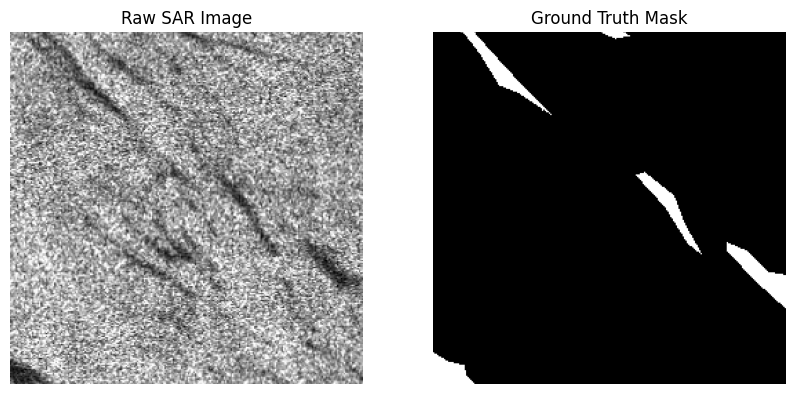

In [37]:
# Get first image name
img_name = sorted(os.listdir(TRAIN_IMG_DIR))[0]

# Load raw image
raw_img = cv2.imread(os.path.join(TRAIN_IMG_DIR, img_name), 0)
raw_mask = cv2.imread(os.path.join(TRAIN_MASK_DIR, img_name), 0)

# Display
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Raw SAR Image")
plt.imshow(raw_img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Ground Truth Mask")
plt.imshow(raw_mask, cmap="gray")
plt.axis("off")
plt.show()

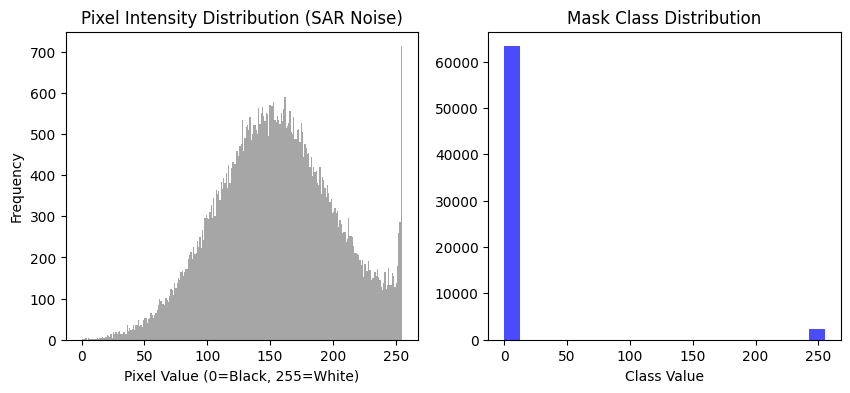

In [39]:
plt.figure(figsize=(10, 4))

# Plot histogram for the image
plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=(0, 255), color='gray', alpha=0.7)
plt.title("Pixel Intensity Distribution (SAR Noise)")
plt.xlabel("Pixel Value (0=Black, 255=White)")
plt.ylabel("Frequency")

# Plot histogram for the mask
plt.subplot(1, 2, 2)
plt.hist(mask.ravel(), bins=20, range=(0, 255), color='blue', alpha=0.7)
plt.title("Mask Class Distribution")
plt.xlabel("Class Value")

plt.show()

In [40]:
def preprocess_data(image_path, mask_path):
    # 1. Read Image and Mask
    image = cv2.imread(image_path, 0)
    mask = cv2.imread(mask_path, 0)

    # 2. Resize to 256x256 (Standard for U-Net)
    image = cv2.resize(image, (256, 256))
    mask = cv2.resize(mask, (256, 256))

    # 3. Denoising (Speckle Noise Reduction)
    image = cv2.medianBlur(image, 5)

    # 4. Normalize (Scale 0-1)
    image = image / 255.0
    mask = mask / 255.0
    mask = (mask > 0.5).astype(np.float32) # Binary threshold

    return image, mask

print("✅ Preprocessing function created.")

✅ Preprocessing function created.


New Shape: (256, 256)
New Values: 0.10196078431372549 to 0.9607843137254902


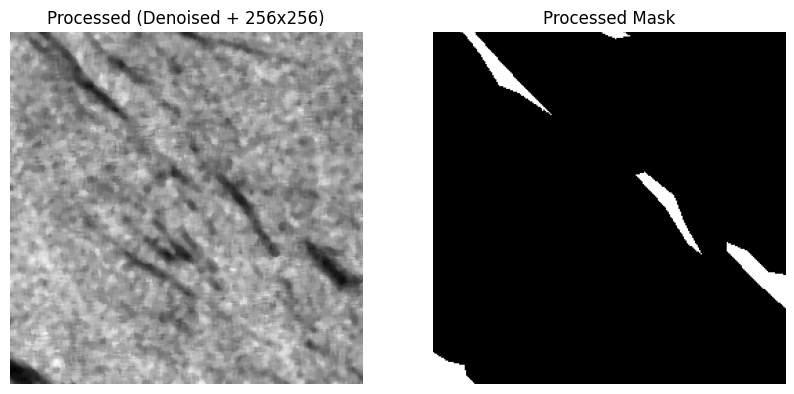

In [41]:
# Call the function
proc_img, proc_mask = preprocess_data(
    os.path.join(TRAIN_IMG_DIR, img_name),
    os.path.join(TRAIN_MASK_DIR, img_name)
)

print(f"New Shape: {proc_img.shape}")
print(f"New Values: {proc_img.min()} to {proc_img.max()}")

# Visualize
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Processed (Denoised + 256x256)")
plt.imshow(proc_img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Processed Mask")
plt.imshow(proc_mask, cmap="gray")
plt.axis("off")
plt.show()

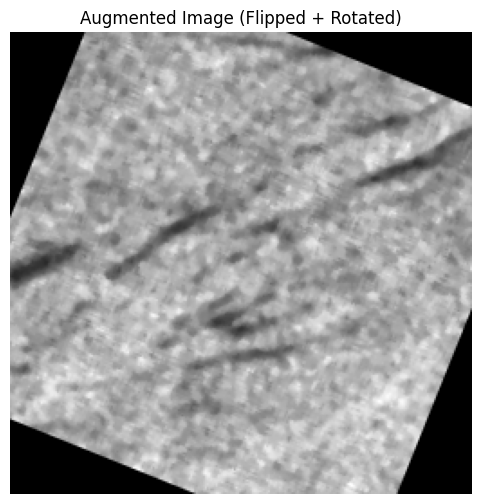

In [42]:
# Define Augmentation Pipeline
aug_pipeline = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=45, p=1.0)
])

# Apply to the processed image
augmented = aug_pipeline(image=proc_img, mask=proc_mask)
aug_img = augmented['image']

# Show Result
plt.figure(figsize=(6, 6))
plt.title("Augmented Image (Flipped + Rotated)")
plt.imshow(aug_img, cmap="gray")
plt.axis("off")
plt.show()